In [1]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/fa/80/eb88edc2e2b11cd2dd2e56f1c80b5784d11d6e6b7f04a1145df64df40065/opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl (39.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install --upgrade matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/6f/d3/a4bbc01c237ab710a1f22b4da72f4ff6d77eb4c7735ea9811a94ae239067/matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 262.6 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 387.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.2/8.1 MB 6.3 MB/s eta 0:00:02
   -- ------------------------------------- 0.4/8.1 MB 5.3 MB/s eta 0:00:02
   --- ------------------------------------ 0.7/8.1 MB 5.2 MB/s eta 0:00:02
   --- ------------------------------------ 0.7/8.1 MB 4.3 MB/s eta 0:00:02
   --- ----------------------

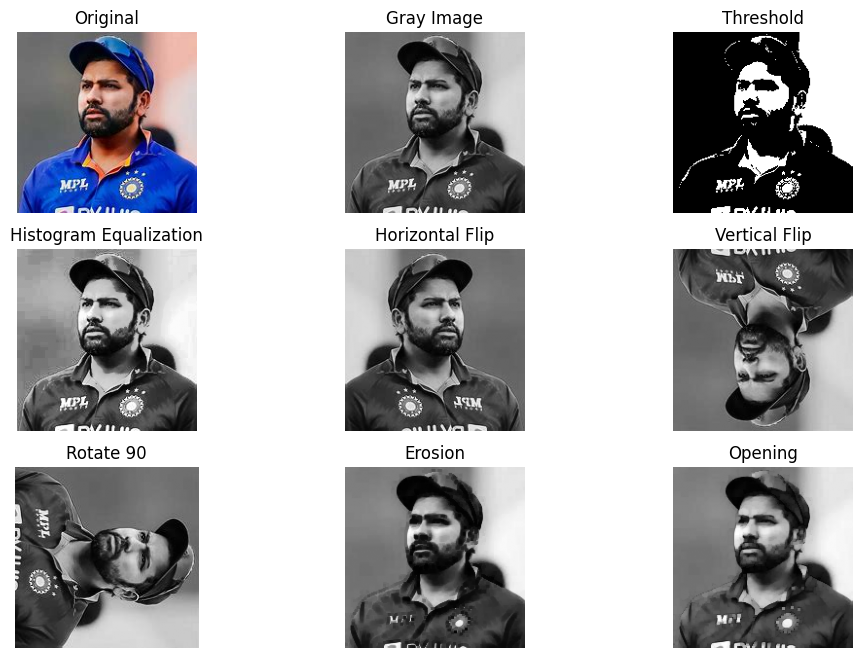

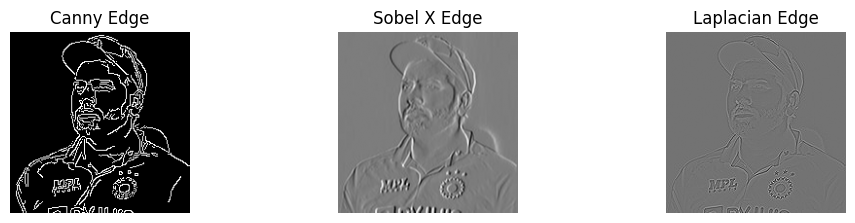

In [68]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
image = cv2.imread("rohit.jpg")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, threshold = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
histequal = cv2.equalizeHist(gray_image)
flip_h = cv2.flip(gray_image, 1)
flip_v = cv2.flip(gray_image, 0)
rotate90 = cv2.rotate(gray_image, cv2.ROTATE_90_CLOCKWISE)
kernel = np.ones((3,3), np.uint8)
erode = cv2.erode(gray_image, kernel, iterations=1)
opening = cv2.morphologyEx(gray_image, cv2.MORPH_OPEN, kernel)
canny = cv2.Canny(gray_image, 100, 200)
sobelx = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)
laplacian = cv2.Laplacian(gray_image, cv2.CV_64F)
images1 = [
    image, gray_image, threshold,
    histequal, flip_h, flip_v,
    rotate90, erode, opening
]
titles1 = [
    "Original", "Gray Image", "Threshold",
    "Histogram Equalization", "Horizontal Flip", "Vertical Flip",
    "Rotate 90", "Erosion", "Opening"
]
plt.figure(figsize=(12, 8))
for i in range(len(images1)):
    plt.subplot(3, 3, i + 1)
    if len(images1[i].shape) == 2: 
        plt.imshow(images1[i], cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(images1[i], cv2.COLOR_BGR2RGB))
    plt.title(titles1[i])
    plt.axis('off')
plt.show()
images2 = [canny, sobelx, laplacian]
titles2 = ["Canny Edge", "Sobel X Edge", "Laplacian Edge"]
plt.figure(figsize=(12, 8))
for i in range(len(images2)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images2[i], cmap='gray')
    plt.title(titles2[i])
    plt.axis('off')
plt.show()


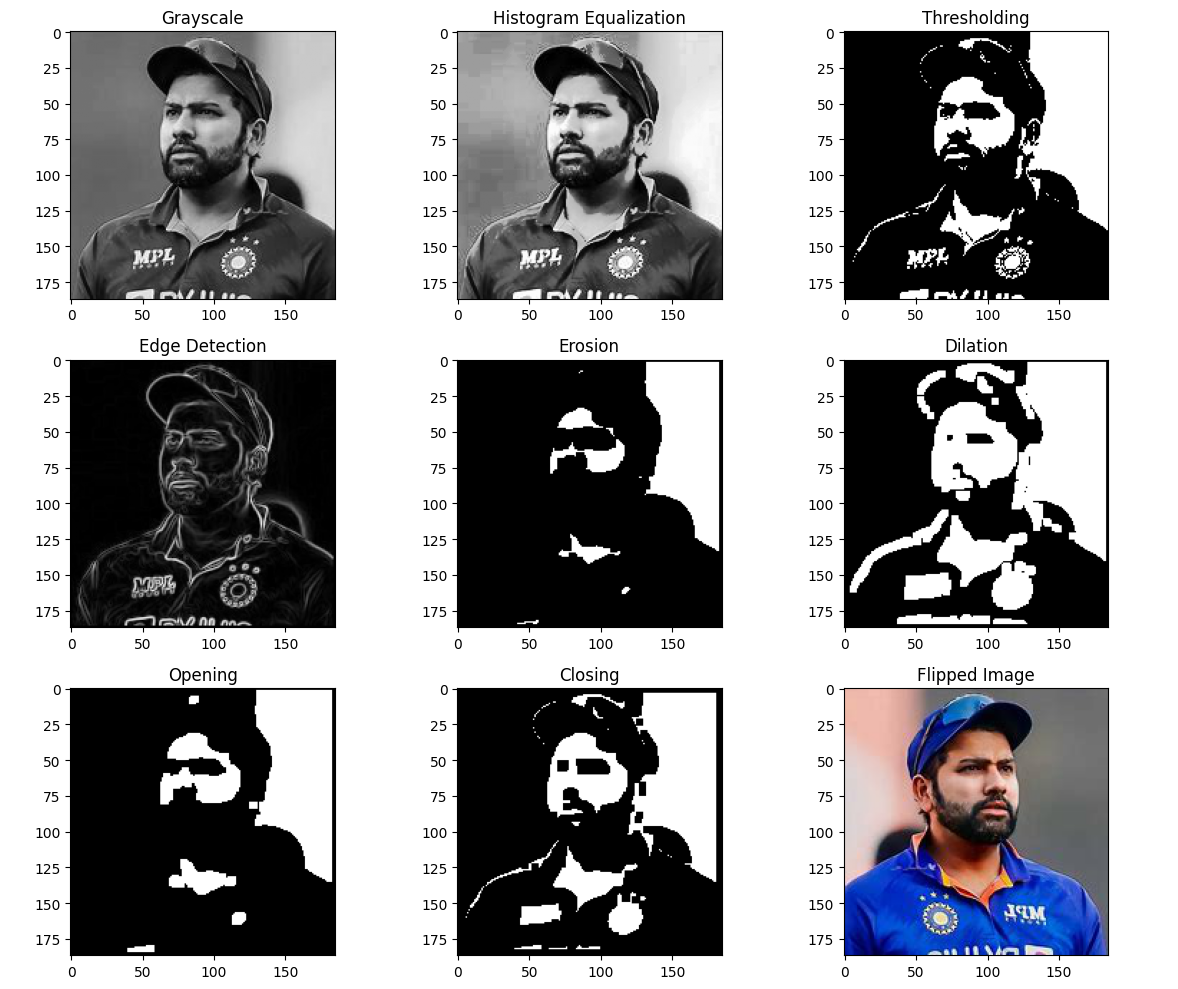

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
img = np.array(Image.open("rohit.jpg"))
gray = (0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]).astype(np.uint8)
hist, bins = np.histogram(gray.flatten(), 256, [0,256])
cdf = hist.cumsum()
cdf = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
hist_eq = cdf[gray].astype(np.uint8)

thresh = np.where(gray > 127, 255, 0).astype(np.uint8)

kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
ky = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

gx = np.zeros_like(gray, dtype=float)
gy = np.zeros_like(gray, dtype=float)

for i in range(1, gray.shape[0]-1):
    for j in range(1, gray.shape[1]-1):
        region = gray[i-1:i+2, j-1:j+2]
        gx[i,j] = np.sum(region * kx)
        gy[i,j] = np.sum(region * ky)

edges = np.sqrt(gx**2 + gy**2)
edges = (edges / edges.max() * 255).astype(np.uint8)

flip = img[:, ::-1]

h, w = gray.shape
angle = np.radians(30)
cos, sin = np.cos(angle), np.sin(angle)
cx, cy = w//2, h//2
rotated = np.zeros_like(img)

for i in range(h):
    for j in range(w):
        x = int(cos*(j-cx) - sin*(i-cy) + cx)
        y = int(sin*(j-cx) + cos*(i-cy) + cy)
        if 0 <= y < h and 0 <= x < w:
            rotated[i,j] = img[y,x]

scaled = img[::2, ::2]

kernel = np.ones((5,5), dtype=np.uint8)

def erode(img):
    out = np.zeros_like(img)
    for i in range(2, img.shape[0]-2):
        for j in range(2, img.shape[1]-2):
            out[i,j] = np.min(img[i-2:i+3, j-2:j+3])
    return out

def dilate(img):
    out = np.zeros_like(img)
    for i in range(2, img.shape[0]-2):
        for j in range(2, img.shape[1]-2):
            out[i,j] = np.max(img[i-2:i+3, j-2:j+3])
    return out

erosion = erode(thresh)
dilation = dilate(thresh)
opening = dilate(erosion)
closing = erode(dilation)

plt.figure(figsize=(12,10))
plt.axis('off')

plt.subplot(3,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")

plt.subplot(3,3,2)
plt.imshow(hist_eq, cmap='gray')
plt.title("Histogram Equalization")

plt.subplot(3,3,3)
plt.imshow(thresh, cmap='gray')
plt.title("Thresholding")

plt.subplot(3,3,4)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")

plt.subplot(3,3,5)
plt.imshow(erosion, cmap='gray')
plt.title("Erosion")

plt.subplot(3,3,6)
plt.imshow(dilation, cmap='gray')
plt.title("Dilation")

plt.subplot(3,3,7)
plt.imshow(opening, cmap='gray')
plt.title("Opening")

plt.subplot(3,3,8)
plt.imshow(closing, cmap='gray')
plt.title("Closing")

plt.subplot(3,3,9)
plt.imshow(flip)
plt.title("Flipped Image")

plt.tight_layout()
plt.show()